## Imports

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

## Load data and inject missing values

Loads the Palmer Penguins dataset and removes 30% of its cells at random (seeded with `np.random.seed(42)` for reproducibility) to create the missing-data scenario.

In [2]:
# Load dataset
penguins = sns.load_dataset('penguins')

np.random.seed(42)  # Set the random seed for reproducibility

# Removing values at random to simulate missing data
removidos = set()
porcentagem = 0.30  # Fraction (0~1) of cells to remove
qtdCelulas = len(penguins)*(len(penguins.columns))  # Total number of cells in the dataset

for i in range(int(np.ceil(porcentagem*qtdCelulas))):
  linha = np.random.randint(0, len(penguins))
  coluna = np.random.randint(0, len(penguins.columns))
  while (linha, coluna) in removidos:
    linha = np.random.randint(0, len(penguins))
    coluna = np.random.randint(0, len(penguins.columns))

  penguins.iloc[linha, coluna] = np.nan
  removidos.add((linha,coluna))

penguins.info()
print("\n\nRemoved ", str(len(removidos)), "cells out of ", str(qtdCelulas))
del removidos
del qtdCelulas
del porcentagem

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            232 non-null    str    
 1   island             241 non-null    str    
 2   bill_length_mm     233 non-null    float64
 3   bill_depth_mm      244 non-null    float64
 4   flipper_length_mm  247 non-null    float64
 5   body_mass_g        240 non-null    float64
 6   sex                235 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


Removed  723 cells out of  2408


---

# Missing Data Imputation — Palmer Penguins

This notebook handles the Palmer Penguins dataset after 30% of its cells were removed at random. The goal is to impute the missing values in a justified way, without distorting the data.

Numerical columns: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
Categorical columns: species, island, sex

Importing what I need beyond the imports above.

In [3]:
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# 1. Initial Exploratory Analysis

Here I look at the dataset before doing anything, to understand what I have and what is missing.

In [4]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            232 non-null    str    
 1   island             241 non-null    str    
 2   bill_length_mm     233 non-null    float64
 3   bill_depth_mm      244 non-null    float64
 4   flipper_length_mm  247 non-null    float64
 5   body_mass_g        240 non-null    float64
 6   sex                235 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [5]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,233.000000,244.000000,247.000000,240.000000
mean,43.696137,17.158197,200.578947,4173.541667
std,5.329054,1.916566,13.935130,784.611381
min,33.500000,13.100000,174.000000,2700.000000
25%,39.200000,15.700000,190.000000,3550.000000
50%,43.600000,17.300000,197.000000,4000.000000
75%,47.500000,18.625000,212.500000,4700.000000
max,58.000000,21.500000,231.000000,6300.000000


In [6]:
# isnull() flags True where there is a NaN, sum() counts those Trues
# result: how many values are missing in each column
print(penguins.isnull().sum())

species              112
island               103
bill_length_mm       111
bill_depth_mm        100
flipper_length_mm     97
body_mass_g          104
sex                  109
dtype: int64


About 30% of each column is missing, which is exactly what was removed. No column is completely empty, so imputation is feasible.

Here I plot the histograms of the numerical columns side by side. `plt.subplot(rows, cols, position)` splits the figure into a grid and places each chart in it.

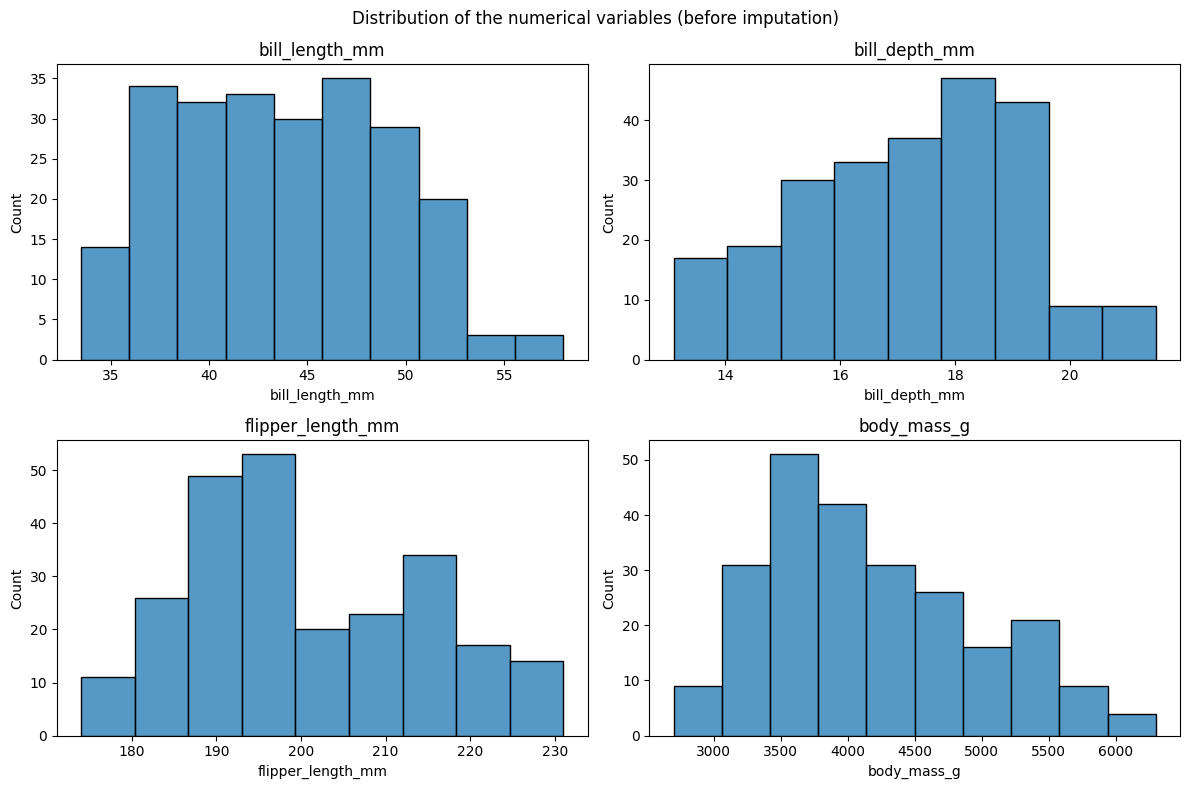

In [7]:
# plt.figure sets the size of the whole figure
# plt.subplot(2, 2, 1) = 2x2 grid, position 1 (top-left)
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(data=penguins, x='bill_length_mm')
plt.title('bill_length_mm')

plt.subplot(2, 2, 2)
sns.histplot(data=penguins, x='bill_depth_mm')
plt.title('bill_depth_mm')

plt.subplot(2, 2, 3)
sns.histplot(data=penguins, x='flipper_length_mm')
plt.title('flipper_length_mm')

plt.subplot(2, 2, 4)
sns.histplot(data=penguins, x='body_mass_g')
plt.title('body_mass_g')

plt.suptitle('Distribution of the numerical variables (before imputation)')
plt.tight_layout()
plt.show()

The distributions have more than one peak (they are multimodal), which indicates that each species forms a different group. That is why the global mean would not be a good choice for imputation — it would fall on a value that represents no real penguin.

Here I plot the frequency of the categorical columns side by side.

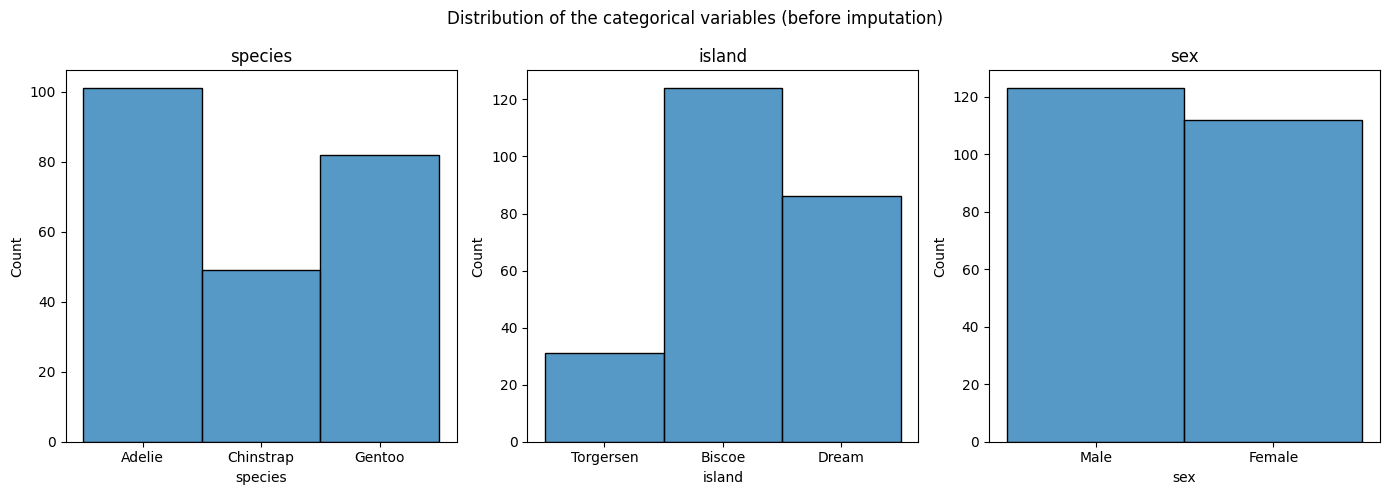

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=penguins, x='species')
plt.title('species')

plt.subplot(1, 3, 2)
sns.histplot(data=penguins, x='island')
plt.title('island')

plt.subplot(1, 3, 3)
sns.histplot(data=penguins, x='sex')
plt.title('sex')

plt.suptitle('Distribution of the categorical variables (before imputation)')
plt.tight_layout()
plt.show()

These proportions are my reference. After imputation I compare them to check that nothing was distorted.

Here I plot boxplots by species to see whether each one occupies a different value range.

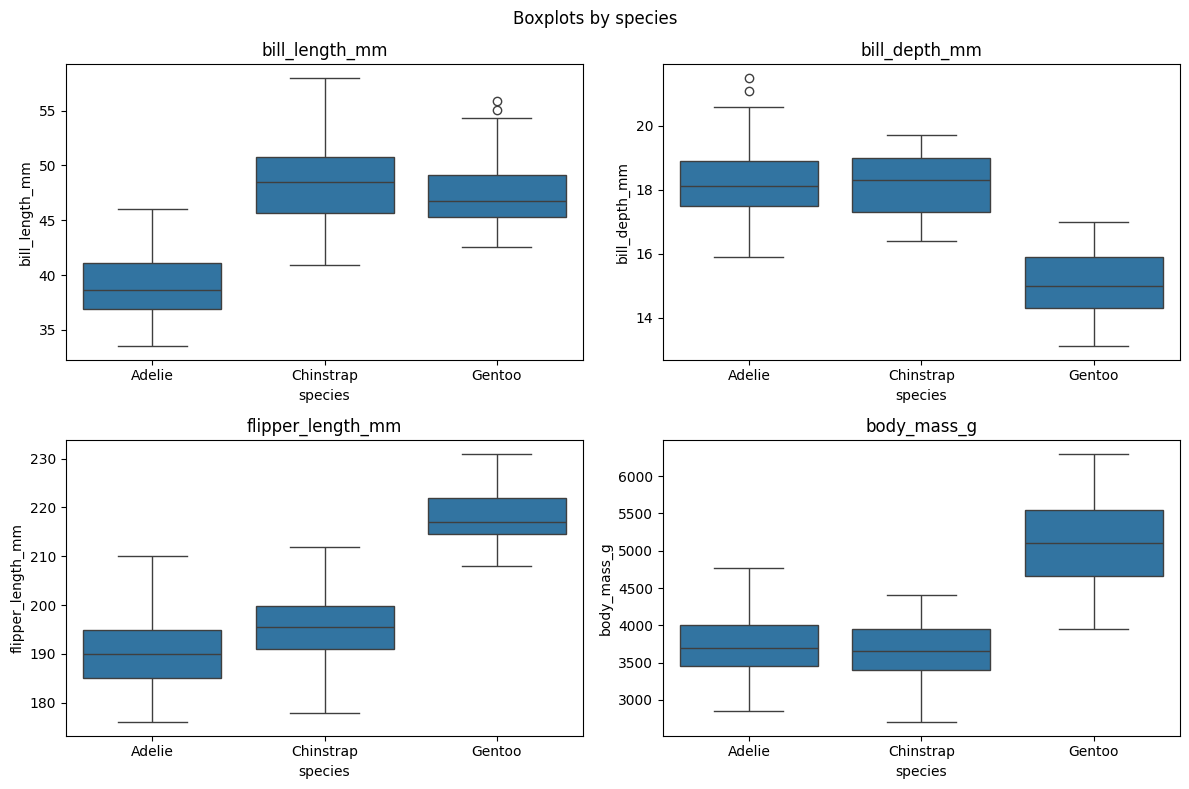

In [9]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.boxplot(data=penguins, x='species', y='bill_length_mm')
plt.title('bill_length_mm')

plt.subplot(2, 2, 2)
sns.boxplot(data=penguins, x='species', y='bill_depth_mm')
plt.title('bill_depth_mm')

plt.subplot(2, 2, 3)
sns.boxplot(data=penguins, x='species', y='flipper_length_mm')
plt.title('flipper_length_mm')

plt.subplot(2, 2, 4)
sns.boxplot(data=penguins, x='species', y='body_mass_g')
plt.title('body_mass_g')

plt.suptitle('Boxplots by species')
plt.tight_layout()
plt.show()

Each species occupies a clearly different range across all measurements. This justifies using KNN: it finds neighbors that are likely from the same species, giving a more accurate estimate than the global mean.

Here I check the correlation between the numerical columns.

In [10]:
# .corr() measures how strongly two columns relate, from -1 to 1
# close to 1: when one goes up, the other goes up too
# this is what KNN needs to work well
colunas_numericas = ['bill_length_mm', 'bill_depth_mm',
                     'flipper_length_mm', 'body_mass_g']

print(penguins[colunas_numericas].corr())

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.192830           0.603790   
bill_depth_mm           -0.192830       1.000000          -0.557765   
flipper_length_mm        0.603790      -0.557765           1.000000   
body_mass_g              0.517256      -0.493668           0.859159   

                   body_mass_g  
bill_length_mm        0.517256  
bill_depth_mm        -0.493668  
flipper_length_mm     0.859159  
body_mass_g           1.000000  


The columns are correlated with each other, especially flipper and body_mass. This is good for KNN: it uses the known columns to estimate the missing one. The more correlated they are, the more accurate the estimate.

Here I save a copy of the dataset with the NaNs to compare later, and export it to Power BI (Dashboard 1).

In [11]:
# .copy() creates an independent copy
# without copy, penguins_antes would just be an alias of penguins
# any change to penguins would also change penguins_antes
penguins_antes = penguins.copy()

# decimal=',' and sep=';' export in the Brazilian format
# required for Power BI to read the values correctly
penguins_antes.to_csv('penguins_inicial.csv', index=False, decimal=',', sep=';')
print("penguins_inicial.csv saved")

penguins_inicial.csv saved


# 2. Imputation of the Numerical Columns

Before choosing the method, I considered 3 options:

1. Drop the rows with NaN
2. Impute with the mean or median
3. Impute with KNN

Dropping the rows would be the worst choice: with 30% of values missing, I would lose more than 100 samples from a dataset that already has only 344. That would drastically reduce the amount of data available to train machine learning algorithms, which is the ultimate goal of this preprocessing.

Imputing with the mean does not work here either. The histograms above show that the distributions have more than one peak (they are multimodal). This happens because each species occupies a different value range, as confirmed by the boxplots. The global mean would fall between these groups, on a value that represents no real penguin. For example, the mean bill length across all species combined would land on a value that no species actually has as a typical value.

That is why I chose the KNN Imputer. The correlation table above shows that the numerical variables are correlated with each other, especially flipper_length_mm and body_mass_g. This means that, knowing some measurements of a penguin, I can estimate the missing ones with good accuracy. KNN does exactly that: it finds the 5 most similar penguins on the columns that exist and uses their mean to estimate the missing column. Since the nearest neighbors are likely from the same species, the estimated value falls in the right range.

About fit, transform and inverse_transform:
- fit: the algorithm reads the data and memorizes the min and max of each column
- transform: applies the 0-1 scaling using what was memorized
- fit_transform: does both at once
- inverse_transform: undoes the scaling, going back to grams and mm

In [12]:
# Step 1: select only the numerical columns
dados_numericos = penguins[colunas_numericas]

# Step 2: scale everything between 0 and 1
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(dados_numericos)

# Step 3: fill the NaNs using KNN with 5 neighbors
imputer = KNNImputer(n_neighbors=5)
dados_imputados = imputer.fit_transform(dados_normalizados)

# Step 4: rescale back to the original units (grams, mm)
dados_imputados = scaler.inverse_transform(dados_imputados)

# Step 5: put the imputed values back into the dataframe
penguins[colunas_numericas] = dados_imputados

print("Missing after numerical imputation:")
print(penguins[colunas_numericas].isnull().sum())

Missing after numerical imputation:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


I used n_neighbors=5 because:
- Too small (e.g. 1): too sensitive to outliers
- Too large (e.g. 50): becomes practically a global mean, losing the advantage of KNN
5 neighbors is a balanced value for a dataset of this size.

Here I compare the histograms before and after imputation to see whether the distribution was preserved. The alpha makes both histograms semi-transparent so both can be seen at the same time. The label names each series and legend() shows the legend box on the chart.

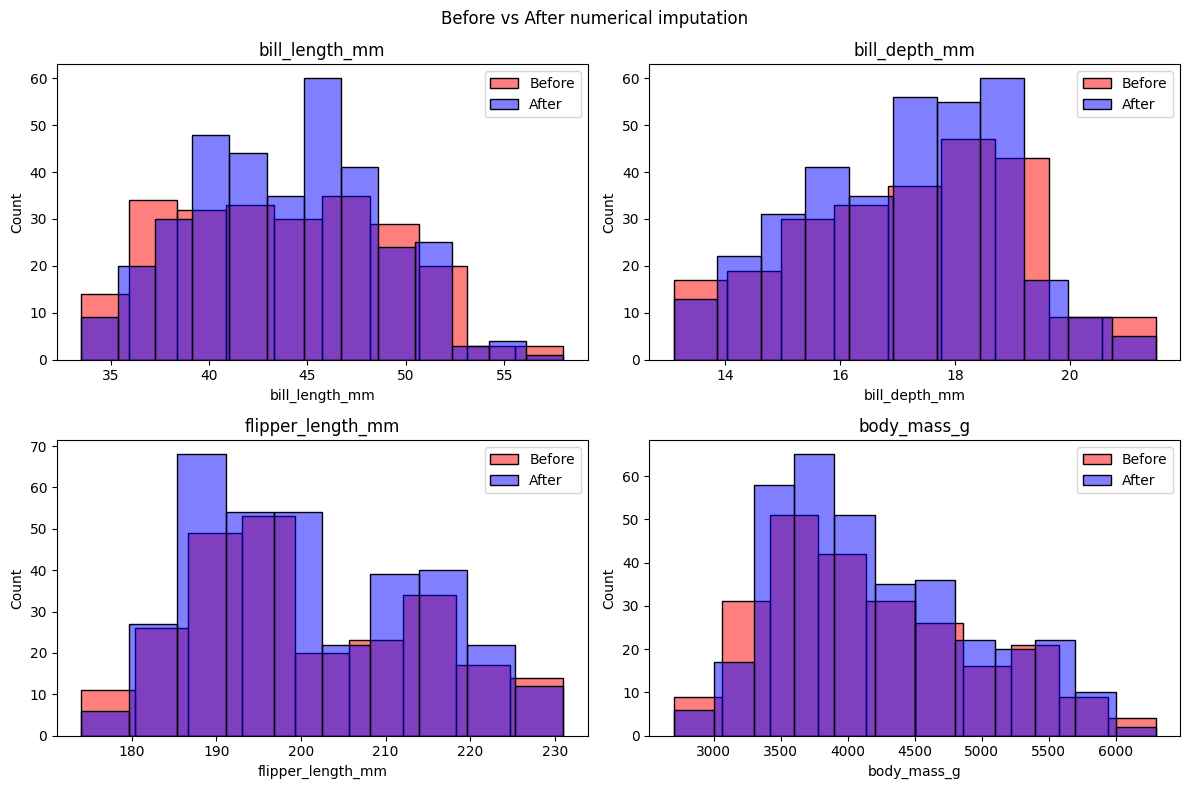

In [13]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(data=penguins_antes, x='bill_length_mm', color='red', label='Before', alpha=0.5)
sns.histplot(data=penguins, x='bill_length_mm', color='blue', label='After', alpha=0.5)
plt.title('bill_length_mm')
plt.legend()

plt.subplot(2, 2, 2)
sns.histplot(data=penguins_antes, x='bill_depth_mm', color='red', label='Before', alpha=0.5)
sns.histplot(data=penguins, x='bill_depth_mm', color='blue', label='After', alpha=0.5)
plt.title('bill_depth_mm')
plt.legend()

plt.subplot(2, 2, 3)
sns.histplot(data=penguins_antes, x='flipper_length_mm', color='red', label='Before', alpha=0.5)
sns.histplot(data=penguins, x='flipper_length_mm', color='blue', label='After', alpha=0.5)
plt.title('flipper_length_mm')
plt.legend()

plt.subplot(2, 2, 4)
sns.histplot(data=penguins_antes, x='body_mass_g', color='red', label='Before', alpha=0.5)
sns.histplot(data=penguins, x='body_mass_g', color='blue', label='After', alpha=0.5)
plt.title('body_mass_g')
plt.legend()

plt.suptitle('Before vs After numerical imputation')
plt.tight_layout()
plt.show()

The histograms confirm that the shape of the distributions was preserved. The peaks remain in the same places, the value scale did not change and no absurd value was inserted.

The statistics table and the correlation table also confirm this: the means, standard deviations and correlations between columns stayed very close to the original values. This shows that KNN respected the structure of the data, something the global mean could not do.

# 3. Imputation of the Categorical Columns

Categorical columns have no mean or numerical distance, so KNN does not apply directly.

The strategy here is the conditional mode: instead of taking the most frequent category of the whole dataset, I take the most frequent one within a relevant group (per species).

Order matters: I impute species first, because island and sex depend on it.

Here I impute species with the global mode.

For species I used the global mode because it is the first column to be imputed and I have no other group to condition on. Adelie is the most frequent species in the dataset, so imputing with it is conservative and minimizes distortion in the dataset proportions.

It would not make sense to use the numerical variables to try to infer the species in a more sophisticated way, since those same variables were just imputed and already carry some uncertainty. The global mode is the safest choice in this context.

In [14]:
# mode() returns the most frequent value, [0] takes the first
moda_species = penguins['species'].mode()[0]
print('Most frequent species:', moda_species)

penguins['species'] = penguins['species'].fillna(moda_species)
print("Missing in species:", penguins['species'].isnull().sum())

Most frequent species: Adelie
Missing in species: 0


Here I check which island is most frequent in each species before imputing island.

For island I cannot use the global mode. The printout below shows that each species has a very clear dominant island: Chinstrap appears almost only on Dream, Gentoo almost only on Biscoe. Using the global mode would assign the same island to every case, which would place Gentoos on islands where they barely exist.

That is why I use the per-species mode: for each penguin with a missing island, I take the most frequent island of its species. This respects the real geographic relationship between species and island.

In [15]:
print('Adelie    ->', penguins[penguins['species'] == 'Adelie']['island'].mode()[0])
print('Chinstrap ->', penguins[penguins['species'] == 'Chinstrap']['island'].mode()[0])
print('Gentoo    ->', penguins[penguins['species'] == 'Gentoo']['island'].mode()[0])

Adelie    -> Biscoe
Chinstrap -> Dream
Gentoo    -> Biscoe


Here I create a function to impute categorical columns using the per-species mode, and apply it to island.

In [16]:
def imputar_por_especie(coluna):
    for especie in ['Adelie', 'Chinstrap', 'Gentoo']:
        mask_especie = penguins['species'] == especie
        moda = penguins.loc[mask_especie, coluna].mode()[0]
        mask_faltante = mask_especie & penguins[coluna].isna()
        penguins.loc[mask_faltante, coluna] = moda

imputar_por_especie('island')
print("Missing in island:", penguins['island'].isnull().sum())

Missing in island: 0


Here I check the relationship between species and sex before imputing sex.

For sex the reasoning is similar to island. The boxplot below shows that males and females have slightly different body-measurement distributions within each species. The proportion of males to females can vary from species to species, so using the global mode would be less accurate than the per-species mode.

In addition, keeping the imputation method consistent across all categorical columns makes the justification easier and the process more organized.

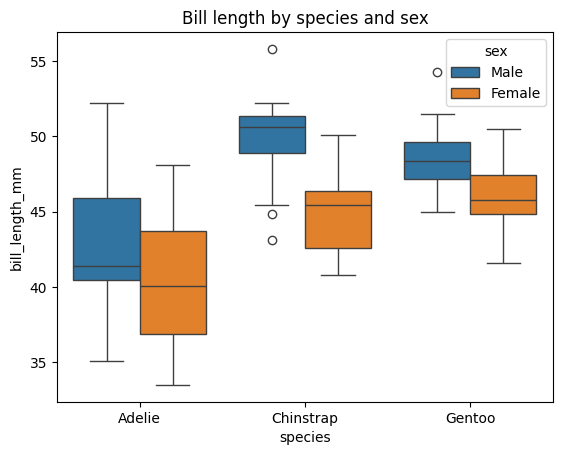

In [17]:
# hue splits the boxes by sex within each species
sns.boxplot(data=penguins, x='species', y='bill_length_mm', hue='sex')
plt.title('Bill length by species and sex')
plt.show()

In [18]:
imputar_por_especie('sex')
print("Missing in sex:", penguins['sex'].isnull().sum())

Missing in sex: 0


In [19]:
print("Missing values after all imputation:")
print(penguins.isnull().sum())

Missing values after all imputation:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


# 4. Final Evaluation

Here I compare the statistics before and after to confirm that imputation did not distort the data.

In [20]:
print("Statistics BEFORE:")
print(penguins_antes[colunas_numericas].describe())
print("\nStatistics AFTER:")
print(penguins[colunas_numericas].describe())

Statistics BEFORE:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      233.000000     244.000000         247.000000   240.000000
mean        43.696137      17.158197         200.578947  4173.541667
std          5.329054       1.916566          13.935130   784.611381
min         33.500000      13.100000         174.000000  2700.000000
25%         39.200000      15.700000         190.000000  3550.000000
50%         43.600000      17.300000         197.000000  4000.000000
75%         47.500000      18.625000         212.500000  4700.000000
max         58.000000      21.500000         231.000000  6300.000000

Statistics AFTER:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      344.000000     344.000000         344.000000   344.000000
mean        43.852618      17.121834         200.896206  4203.597989
std          4.751960       1.760401          13.078385   747.072024
min         33.500000      13.100000         174.000000  2700.000

Here I compare the correlation before and after to check that the relationships between columns were preserved.

In [21]:
print("Correlation BEFORE:")
print(penguins_antes[colunas_numericas].corr())
print("\nCorrelation AFTER:")
print(penguins[colunas_numericas].corr())

Correlation BEFORE:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.192830           0.603790   
bill_depth_mm           -0.192830       1.000000          -0.557765   
flipper_length_mm        0.603790      -0.557765           1.000000   
body_mass_g              0.517256      -0.493668           0.859159   

                   body_mass_g  
bill_length_mm        0.517256  
bill_depth_mm        -0.493668  
flipper_length_mm     0.859159  
body_mass_g           1.000000  

Correlation AFTER:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.284782           0.634761   
bill_depth_mm           -0.284782       1.000000          -0.581959   
flipper_length_mm        0.634761      -0.581959           1.000000   
body_mass_g              0.604142      -0.532720           0.873462   

                   body_mass_g  
bill_length_mm        0.604142  
bill_depth_mm    

Here I check the categorical proportions after imputation to compare with what I had before.

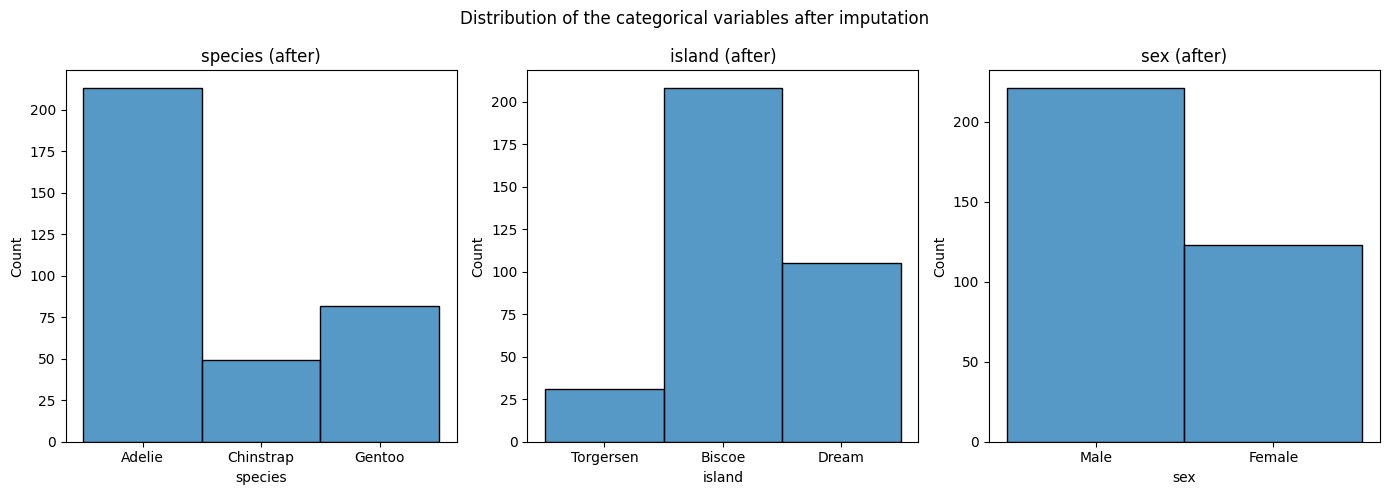

In [22]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=penguins, x='species')
plt.title('species (after)')

plt.subplot(1, 3, 2)
sns.histplot(data=penguins, x='island')
plt.title('island (after)')

plt.subplot(1, 3, 3)
sns.histplot(data=penguins, x='sex')
plt.title('sex (after)')

plt.suptitle('Distribution of the categorical variables after imputation')
plt.tight_layout()
plt.show()

The proportions stayed consistent with the original dataset. The means, standard deviations and correlations also remained close to the original values. This confirms that the imputation was appropriate.

Here I export the imputed dataset to use in Power BI (Dashboard 2).

In [23]:
penguins.to_csv('penguins_imputado.csv', index=False, decimal=',', sep=';')
print("penguins_imputado.csv saved")
print("\nRemaining missing values:")
print(penguins.isnull().sum())

penguins_imputado.csv saved

Remaining missing values:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
